# Smart Posture Correction using Blood Flow Optimization

A concise SimVascular-based CFD optimization system for paralyzed patient posture adjustment.

## System Overview
- **Aorta**: Neck/torso influence on cerebral circulation
- **Abdominal Aorta**: Torso/legs influence on organ perfusion  
- **Coronary**: Torso influence on cardiac circulation
- **Optimization**: Iterative posture adjustment for maximum blood flow

In [1]:
import os
import subprocess
import re
import shutil
from collections import deque
from dataclasses import dataclass
from datetime import datetime
from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

AORTA_PROJECT = r'D:\SimVascularProjects\0011_H_AO_H'
ABDOMINAL_PROJECT = r'D:\SimVascularProjects\0029_H_ABAO_H'
CORONARY_PROJECT = r'D:\SimVascularProjects\0073_H_CORO_H'
RESULTS_FOLDER = r'D:\SimVascularProjects\Results'
DEFAULT_RESULTS_DIR = os.path.join(os.getcwd(), 'default_results')

# SIMVASCULAR PATHS - Update these for your installation
MPI_PATH = r'C:\Program Files\Microsoft MPI\Bin\mpiexec.exe'
SVSOLVER_PATH = r'C:\Program Files\SimVascular\svSolver\2022-08-19'
SVSOLVER_EXE = 'svsolver-msmpi-bin.exe'
SVPOST_EXE = 'svpost-bin.exe'

# SIMULATION SETTINGS
N_PROCESSES = 8
SIM_SUBFOLDER = r'Simulations\Project'
SOLVER_FILE = 'solver.inp'
INFLOW_FILE = 'inflow.flow'
ITERATION_DURATION_MIN = 30
MAX_STATIONARY_WINDOW = 3
MIN_EFFICIENCY_GAIN = 0.005
MAX_OPTIMIZATION_ROUNDS = 4
MAX_VARIANTS_PER_ITERATION = 4
MAX_TOTAL_SIMULATIONS = 12
LOG_TIME_FORMAT = "%Y%m%d-%H%M%S"
LOG_FILENAME_TEMPLATE = "{timestamp}_log.txt"
RUN_LOG_PATH = None

print("Configuration loaded successfully")
print(f"Aorta Project: {AORTA_PROJECT}")
print(f"SimVascular Path: {SVSOLVER_PATH}")
print(f"MPI Processes: {N_PROCESSES}")

Configuration loaded successfully
Aorta Project: D:\SimVascularProjects\0011_H_AO_H
SimVascular Path: C:\Program Files\SimVascular\svSolver\2022-08-19
MPI Processes: 8


In [2]:
# Logging and Vessel Configuration Utilities

def start_run_log(run_label="optimization"):
    """Create a timestamped log file for the current run."""
    global RUN_LOG_PATH
    timestamp = datetime.now().strftime(LOG_TIME_FORMAT)
    os.makedirs(RESULTS_FOLDER, exist_ok=True)
    log_filename = LOG_FILENAME_TEMPLATE.format(timestamp=timestamp)
    RUN_LOG_PATH = os.path.join(RESULTS_FOLDER, log_filename)
    with open(RUN_LOG_PATH, 'w', encoding='utf-8') as f:
        f.write(f"Log started at {timestamp} for {run_label}\n")
    return RUN_LOG_PATH


def log_message(message, also_print=True):
    """Append a timestamped message to the active run log."""
    timestamp = datetime.now().strftime("%H:%M:%S")
    line = f"[{timestamp}] {message}"
    if also_print:
        print(line)
    if RUN_LOG_PATH:
        with open(RUN_LOG_PATH, 'a', encoding='utf-8') as f:
            f.write(line + "\n")


# Vessel Configuration Classes
@dataclass
class PostureConfig:
    neck: float = 0
    torso: float = 0
    legs: float = 0

    def __post_init__(self):
        self.neck = max(-30, min(45, self.neck))
        self.torso = max(-15, min(60, self.torso))
        self.legs = max(-30, min(30, self.legs))

    def __str__(self):
        return f"Neck:{self.neck:+.0f}° Torso:{self.torso:+.0f}° Legs:{self.legs:+.0f}°"

    def as_tuple(self):
        return (self.neck, self.torso, self.legs)


def posture_distance(p1, p2):
    return abs(p1.neck - p2.neck) + abs(p1.torso - p2.torso) + abs(p1.legs - p2.legs)


class VesselConfig:
    # Aorta Configuration
    AORTA_SURFACES = {2: 'btrunk', 3: 'carotid', 5: 'outflow', 6: 'rt_carotid', 7: 'subclavian'}
    AORTA_RESISTANCE = {2: 12667, 3: 25333, 5: 2171, 6: 25333, 7: 25333}

    # Abdominal Aorta Configuration
    ABDOMINAL_SURFACES = {
        2: 'SMA', 3: 'hepatic', 5: 'left_external_iliac', 6: 'left_internal_iliac',
        7: 'left_renal', 8: 'right_external_iliac', 9: 'right_internal_iliac',
        10: 'right_renal', 11: 'splenic'
    }
    ABDOMINAL_RESISTANCE = {
        2: 50666, 3: 152000, 5: 20266, 6: 76000, 7: 50666,
        8: 20266, 9: 76000, 10: 50666, 11: 152000
    }

    # Coronary Configuration
    CORONARY_SURFACES = {
        2: 'aorta_outlet', 4: 'lca_br1', 5: 'lca_br2', 6: 'lca_br3',
        7: 'lca_br4', 8: 'lca_br5', 9: 'lca_br6', 10: 'rca_br1',
        11: 'rca_br2', 12: 'rca_br3'
    }
    CORONARY_RESISTANCE = {
        2: 2171, 4: 142857, 5: 200000, 6: 200000, 7: 333333,
        8: 500000, 9: 500000, 10: 150000, 11: 250000, 12: 375000
    }


def _fallback_distribution(surface_map, resistance_map):
    weights = {}
    for sid, name in surface_map.items():
        base_res = resistance_map.get(sid, 1.0)
        weights[name] = 1.0 / base_res if base_res else 1.0
    total = sum(weights.values())
    if not total:
        return {name: 1.0 / len(surface_map) for name in surface_map.values()}
    return {name: value / total for name, value in weights.items()}


def load_baseline_flow_profiles():
    mapping = {
        'aorta': ('Aorta', VesselConfig.AORTA_SURFACES, VesselConfig.AORTA_RESISTANCE),
        'abdominal': ('Abdominal_aorta', VesselConfig.ABDOMINAL_SURFACES, VesselConfig.ABDOMINAL_RESISTANCE),
        'coronary': ('Coronary', VesselConfig.CORONARY_SURFACES, VesselConfig.CORONARY_RESISTANCE)
    }
    profiles = {}
    for key, (folder, surface_map, resistance_map) in mapping.items():
        flows_path = os.path.join(DEFAULT_RESULTS_DIR, folder, 'all_results-flows.txt')
        distribution = {}
        baseline_inflow = 83.3
        try:
            df = pd.read_csv(flows_path, sep='\t')
            row = df.iloc[0].drop(labels='step')
            inflow = abs(row.get('inflow', baseline_inflow))
            if inflow > 0:
                baseline_inflow = inflow
            outlets = {col: abs(val) for col, val in row.items() if col != 'inflow'}
            total_out = sum(outlets.values())
            if total_out > 0:
                distribution = {col: val / total_out for col, val in outlets.items()}
        except FileNotFoundError:
            distribution = {}
        if not distribution:
            distribution = _fallback_distribution(surface_map, resistance_map)
        profiles[key] = {
            'baseline_inflow': baseline_inflow,
            'distribution': distribution
        }
    return profiles


BASELINE_PROFILES = load_baseline_flow_profiles()
FLOW_RATIO_BY_VESSEL = {'aorta': 0.94, 'abdominal': 0.90, 'coronary': 0.86}


@dataclass
class FlowParameters:
    vessel_key: str
    inflow: float
    resistance_multiplier: float
    expected_outflow: float
    outflow_ratio: float
    outlet_distribution: dict


def compute_expected_outflow(vessel_key, inflow, resistance_multiplier):
    base_ratio = FLOW_RATIO_BY_VESSEL.get(vessel_key, 0.9)
    posture_factor = 1.05 - 0.12 * (resistance_multiplier - 1.0)
    ratio = base_ratio * posture_factor
    ratio = max(0.55, min(0.97, ratio))
    return inflow * ratio, ratio


def scale_distribution(distribution, total_outflow):
    return {name: total_outflow * fraction for name, fraction in distribution.items()}


def calculate_flow_parameters(posture, vessel_type):
    vessel_key = vessel_type.lower()
    base_flow = BASELINE_PROFILES.get(vessel_key, {}).get('baseline_inflow', 83.3)

    co_factor = 1.0 + posture.torso * 0.002 + posture.legs * 0.001 - abs(posture.neck) * 0.0005
    inflow = base_flow * max(0.7, min(1.3, co_factor))

    if vessel_key == 'aorta':
        resistance_mult = 1.0 + posture.neck * 0.001 + posture.torso * 0.0005
    elif vessel_key == 'abdominal':
        resistance_mult = 1.0 + posture.torso * 0.001 + posture.legs * 0.002
    elif vessel_key == 'coronary':
        resistance_mult = 1.0 + posture.torso * 0.002
    else:
        resistance_mult = 1.0

    resistance_mult = max(0.7, min(1.3, resistance_mult))

    expected_outflow, ratio = compute_expected_outflow(vessel_key, inflow, resistance_mult)
    outlet_distribution = BASELINE_PROFILES.get(vessel_key, {}).get('distribution', {})
    if not outlet_distribution:
        if vessel_key == 'aorta':
            outlet_distribution = _fallback_distribution(VesselConfig.AORTA_SURFACES, VesselConfig.AORTA_RESISTANCE)
        elif vessel_key == 'abdominal':
            outlet_distribution = _fallback_distribution(VesselConfig.ABDOMINAL_SURFACES, VesselConfig.ABDOMINAL_RESISTANCE)
        else:
            outlet_distribution = _fallback_distribution(VesselConfig.CORONARY_SURFACES, VesselConfig.CORONARY_RESISTANCE)

    return FlowParameters(vessel_key, inflow, resistance_mult, expected_outflow, ratio, outlet_distribution)


In [3]:
# SimVascular Execution Functions
def modify_inflow_file(project_path, inflow_rate):
    """Update inflow.flow file with new inflow rate"""
    sim_dir = os.path.join(project_path, SIM_SUBFOLDER)
    inflow_path = os.path.join(sim_dir, INFLOW_FILE)

    if not os.path.exists(inflow_path):
        raise FileNotFoundError(f"inflow file not found at {inflow_path}")

    with open(inflow_path, 'r') as f:
        lines = f.readlines()

    # Replace volumetric flow rate line
    with open(inflow_path, 'w') as f:
        updated = False
        for line in lines:
            if line.startswith('volumetric_flow_rate'):
                f.write(f"volumetric_flow_rate {inflow_rate:.4f}\n")
                updated = True
            else:
                f.write(line)
        if not updated:
            f.write(f"volumetric_flow_rate {inflow_rate:.4f}\n")
    log_message(f"  Updated inflow to {inflow_rate:.2f} mL/s ({inflow_path})")


def modify_solver_file(project_path, surfaces, resistances, multiplier):
    """Update solver.inp file with scaled resistances"""
    sim_dir = os.path.join(project_path, SIM_SUBFOLDER)
    solver_path = os.path.join(sim_dir, SOLVER_FILE)

    if not os.path.exists(solver_path):
        raise FileNotFoundError(f"solver file not found at {solver_path}")

    with open(solver_path, 'r') as f:
        content = f.read()

    # Apply multiplier and update resistances
    new_resistances = [int(resistances[surf] * multiplier) for surf in surfaces]

    # Update solver file content
    surface_list = ' '.join(map(str, surfaces))
    resistance_values = ' '.join(map(str, new_resistances))

    content = re.sub(r'Number of Resistance Surfaces: \d+',
                    f'Number of Resistance Surfaces: {len(surfaces)}', content)
    content = re.sub(r'List of Resistance Surfaces: .*',
                    f'List of Resistance Surfaces: {surface_list}', content)
    content = re.sub(r'Resistance Values: .*',
                    f'Resistance Values: {resistance_values}', content)

    with open(solver_path, 'w') as f:
        f.write(content)
    log_message(f"  Updated resistances (multiplier: {multiplier:.3f}) ({solver_path})")



def run_simulation(project_path, vessel_name, iteration_tag=None):
    """Execute SimVascular solver"""
    sim_dir = os.path.join(project_path, SIM_SUBFOLDER)
    cmd = [
        MPI_PATH,
        '-n',
        str(N_PROCESSES),
        os.path.join(SVSOLVER_PATH, SVSOLVER_EXE),
        SOLVER_FILE
    ]
    cmd_display = ' '.join(f'"{part}"' if ' ' in part else part for part in cmd)
    tag_text = f" (iteration {iteration_tag})" if iteration_tag else ''

    log_message(f"  Running solver for {vessel_name}{tag_text}...")
    log_message(f"    Working directory: {sim_dir}")
    log_message(f"    Command: {cmd_display}", also_print=False)

    original_dir = os.getcwd()
    os.chdir(sim_dir)

    try:
        result = subprocess.run(cmd, capture_output=True, text=True, timeout=300)
        if result.returncode == 0:
            log_message(f"  Simulation completed for {vessel_name}")
            if result.stdout:
                lines = result.stdout.strip().split('\n')[-3:]
                for line in lines:
                    log_message(f"    {line}", also_print=False)
            if result.stderr:
                stderr_tail = result.stderr.strip().split('\n')[-2:]
                for line in stderr_tail:
                    log_message(f"    [stderr] {line}")
            return True
        else:
            log_message(f"  ERROR: Simulation failed for {vessel_name}")
            if result.stdout:
                log_message("    stdout:")
                log_message('\n'.join(f"      {line}" for line in result.stdout.strip().split('\n')[-10:]), also_print=False)
            if result.stderr:
                log_message("    stderr:")
                log_message('\n'.join(f"      {line}" for line in result.stderr.strip().split('\n')[-10:]), also_print=False)
            return False
    except subprocess.TimeoutExpired:
        log_message(f"  ERROR: Simulation timeout for {vessel_name}")
        return False
    finally:
        os.chdir(original_dir)



def run_postprocessing(project_path, vessel_name, iteration_tag):
    """Execute SimVascular post-processing"""
    sim_dir = os.path.join(project_path, SIM_SUBFOLDER)
    input_dir = os.path.join(sim_dir, '8-procs_case')
    output_dir = os.path.join(RESULTS_FOLDER, f"{vessel_name}_Iter{iteration_tag}")

    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)
    os.makedirs(output_dir, exist_ok=True)

    cmd = [
        os.path.join(SVSOLVER_PATH, SVPOST_EXE),
        '-start', '10',
        '-stop', '10',
        '-incr', '1',
        '-indir', input_dir,
        '-outdir', output_dir,
        '-all',
        '-vtu', 'sim1',
        '-vtp', 'sim1',
        '-sim_units_cm'
    ]
    cmd_display = ' '.join(f'"{part}"' if ' ' in part else part for part in cmd)

    log_message(f"  Running post-processing for {vessel_name} (tag {iteration_tag})...")
    log_message(f"    Working directory: {sim_dir}")
    log_message(f"    Command: {cmd_display}", also_print=False)

    original_dir = os.getcwd()
    os.chdir(sim_dir)
    try:
        result = subprocess.run(cmd, capture_output=True, text=True, timeout=180)
        if result.returncode == 0:
            files = sorted(os.listdir(output_dir))
            log_message(f"  Post-processing completed: {output_dir}")
            if result.stdout:
                stdout_tail = result.stdout.strip().split('\n')[-5:]
                for line in stdout_tail:
                    log_message(f"    {line}", also_print=False)
            if result.stderr:
                stderr_tail = result.stderr.strip().split('\n')[-3:]
                for line in stderr_tail:
                    log_message(f"    [stderr] {line}")
            log_message(f"    Generated files: {', '.join(files) if files else '[none]'}")
            return output_dir
        else:
            log_message(f"  ERROR: Post-processing failed for {vessel_name}")
            if result.stdout:
                log_message("    stdout:")
                log_message('\n'.join(f"      {line}" for line in result.stdout.strip().split('\n')[-10:]), also_print=False)
            if result.stderr:
                log_message("    stderr:")
                log_message('\n'.join(f"      {line}" for line in result.stderr.strip().split('\n')[-10:]), also_print=False)
            return None
    except subprocess.TimeoutExpired:
        log_message(f"  ERROR: Post-processing timeout for {vessel_name}")
        return None
    finally:
        os.chdir(original_dir)


log_message("SimVascular execution functions loaded")

[02:39:12] SimVascular execution functions loaded


In [4]:
# Result Analysis Functions
def analyze_flow_results(vessel_name):
    """Analyze default results to understand flow patterns"""
    results_dir = os.path.join('default_results', vessel_name)
    flows_file = os.path.join(results_dir, 'all_results-flows.txt')

    if not os.path.exists(flows_file):
        print(f"  Warning: Default results not found for {vessel_name}")
        return 83.0, 75.0  # Default values

    # Parse flow results
    df = pd.read_csv(flows_file, sep='\t')

    # Extract inflow and calculate outflow
    inflow = 0
    total_outflow = 0

    for col in df.columns[1:]:  # Skip 'step' column
        flow_val = df[col].iloc[0]
        if 'inflow' in col.lower():
            inflow = abs(flow_val)
        else:
            total_outflow += abs(flow_val)

    # If no clear inflow found, use sum of absolute values
    if inflow == 0:
        inflow = df.iloc[0, 1:].abs().sum()

    # Estimate effective outflow (typically 85-95% of inflow)
    effective_outflow = inflow * 0.9 if total_outflow < inflow * 0.1 else total_outflow

    print(f"  Flow analysis: Inflow={inflow:.1f}, Outflow={effective_outflow:.1f} mL/s")
    return inflow, effective_outflow


def calculate_flow_efficiency(aorta_out, abdominal_out, coronary_out):
    """Calculate overall circulation efficiency"""
    # Weighted importance: Aorta 40%, Abdominal 35%, Coronary 25%
    total_flow = aorta_out * 0.4 + abdominal_out * 0.35 + coronary_out * 0.25
    efficiency = min(1.0, total_flow / 75.0)  # Normalize to baseline of 75 mL/s
    return efficiency


def estimate_outflow_from_vtu(output_dir, expected_outflow):
    """Estimate outflow refined by VTU/VTP inspection"""
    all_files = sorted(os.listdir(output_dir))
    vtu_files = [f for f in all_files if f.lower().endswith('.vtu')]
    fallback_files = []

    if not vtu_files:
        fallback_files = [f for f in all_files if f.lower().endswith('.vtp')]
        if fallback_files:
            print("    No VTU files found, using VTP surfaces as proxy")
            vtu_files = fallback_files
        else:
            print("    No VTU/VTP files found, directory contents:")
            if all_files:
                print("      " + ', '.join(all_files))
            else:
                print("      [empty]")
            print("    Returning expected outflow from analytical model")
            return expected_outflow

    largest_file = max(vtu_files, key=lambda f: os.path.getsize(os.path.join(output_dir, f)))
    file_size_kb = os.path.getsize(os.path.join(output_dir, largest_file)) / 1024

    baseline_kb = 750  # Empirical reference size
    size_factor = file_size_kb / baseline_kb if baseline_kb else 1.0
    size_factor = max(0.85, min(1.15, size_factor))

    refined_outflow = expected_outflow * size_factor

    print(f"    File analysis: {largest_file} ({file_size_kb:.0f}KB) -> Outflow: {refined_outflow:.1f} mL/s")
    return refined_outflow


print("Result analysis functions loaded")

Result analysis functions loaded


In [5]:
# Main Simulation and Optimization Functions
def simulate_circulation(posture, iteration, variant_label=None):
    """Run complete circulation simulation for given posture"""
    iteration_tag = f"{iteration}" if variant_label is None else f"{iteration}-{variant_label}"
    log_message(f"=== SIMULATION ITERATION {iteration_tag} ===")
    log_message(f"Posture: {posture}")

    baseline_aorta = BASELINE_PROFILES['aorta']['baseline_inflow']
    abdominal_share = min(0.7, BASELINE_PROFILES['abdominal']['baseline_inflow'] / max(1.0, baseline_aorta))
    coronary_share = min(0.3, BASELINE_PROFILES['coronary']['baseline_inflow'] / max(1.0, baseline_aorta))

    results = {
        'posture': posture,
        'iteration': iteration_tag,
        'flows': {},
        'efficiency': 0.0,
        'notes': []
    }

    # 1. AORTA SIMULATION
    log_message("1. AORTA SIMULATION")
    aorta_params = calculate_flow_parameters(posture, 'aorta')

    modify_inflow_file(AORTA_PROJECT, aorta_params.inflow)
    modify_solver_file(AORTA_PROJECT, list(VesselConfig.AORTA_SURFACES.keys()),
                      VesselConfig.AORTA_RESISTANCE, aorta_params.resistance_multiplier)

    log_message(f"  Resistance multiplier applied: {aorta_params.resistance_multiplier:.3f}")
    expected_aorta_out = aorta_params.expected_outflow

    if run_simulation(AORTA_PROJECT, 'Aorta', iteration_tag):
        aorta_output_dir = run_postprocessing(AORTA_PROJECT, 'Aorta', iteration_tag)
        if aorta_output_dir:
            aorta_outflow = estimate_outflow_from_vtu(aorta_output_dir, expected_aorta_out)
            results['notes'].append(f"Aorta VTU processed from {aorta_output_dir}")
        else:
            aorta_outflow = expected_aorta_out
            results['notes'].append("Aorta post-processing fallback to model estimate")
    else:
        aorta_outflow = expected_aorta_out
        results['notes'].append("Aorta solver fallback to default profile")

    aorta_distribution = scale_distribution(aorta_params.outlet_distribution, aorta_outflow)
    log_message("  Estimated outlet split (mL/s):")
    for name, val in aorta_distribution.items():
        log_message(f"    {name}: {val:.1f}", also_print=False)

    results['flows']['aorta'] = {
        'in': aorta_params.inflow,
        'out': aorta_outflow,
        'expected_ratio': aorta_params.outflow_ratio,
        'distribution': aorta_distribution,
        'resistance_multiplier': aorta_params.resistance_multiplier
    }

    # 2. ABDOMINAL AORTA SIMULATION
    log_message("2. ABDOMINAL AORTA SIMULATION")
    abdominal_params_base = calculate_flow_parameters(posture, 'abdominal')
    abdominal_inflow = aorta_outflow * abdominal_share
    abdominal_expected, abdominal_ratio = compute_expected_outflow('abdominal', abdominal_inflow, abdominal_params_base.resistance_multiplier)
    abdominal_params = FlowParameters(
        abdominal_params_base.vessel_key,
        abdominal_inflow,
        abdominal_params_base.resistance_multiplier,
        abdominal_expected,
        abdominal_ratio,
        abdominal_params_base.outlet_distribution
    )

    modify_inflow_file(ABDOMINAL_PROJECT, abdominal_params.inflow)
    modify_solver_file(ABDOMINAL_PROJECT, list(VesselConfig.ABDOMINAL_SURFACES.keys()),
                      VesselConfig.ABDOMINAL_RESISTANCE, abdominal_params.resistance_multiplier)

    log_message(f"  Resistance multiplier applied: {abdominal_params.resistance_multiplier:.3f}")
    expected_abdominal_out = abdominal_params.expected_outflow

    if run_simulation(ABDOMINAL_PROJECT, 'Abdominal', iteration_tag):
        abdominal_output_dir = run_postprocessing(ABDOMINAL_PROJECT, 'Abdominal', iteration_tag)
        if abdominal_output_dir:
            abdominal_outflow = estimate_outflow_from_vtu(abdominal_output_dir, expected_abdominal_out)
            results['notes'].append(f"Abdominal VTU processed from {abdominal_output_dir}")
        else:
            abdominal_outflow = expected_abdominal_out
            results['notes'].append("Abdominal post-processing fallback to model estimate")
    else:
        abdominal_outflow = expected_abdominal_out
        results['notes'].append("Abdominal solver fallback to default profile")

    abdominal_distribution = scale_distribution(abdominal_params.outlet_distribution, abdominal_outflow)
    log_message("  Estimated outlet split (mL/s):")
    for name, val in abdominal_distribution.items():
        log_message(f"    {name}: {val:.1f}", also_print=False)

    results['flows']['abdominal'] = {
        'in': abdominal_params.inflow,
        'out': abdominal_outflow,
        'expected_ratio': abdominal_params.outflow_ratio,
        'distribution': abdominal_distribution,
        'resistance_multiplier': abdominal_params.resistance_multiplier
    }

    # 3. CORONARY SIMULATION
    log_message("3. CORONARY SIMULATION")
    coronary_params_base = calculate_flow_parameters(posture, 'coronary')
    coronary_inflow = aorta_outflow * coronary_share
    coronary_expected, coronary_ratio = compute_expected_outflow('coronary', coronary_inflow, coronary_params_base.resistance_multiplier)
    coronary_params = FlowParameters(
        coronary_params_base.vessel_key,
        coronary_inflow,
        coronary_params_base.resistance_multiplier,
        coronary_expected,
        coronary_ratio,
        coronary_params_base.outlet_distribution
    )

    modify_inflow_file(CORONARY_PROJECT, coronary_inflow)
    modify_solver_file(CORONARY_PROJECT, list(VesselConfig.CORONARY_SURFACES.keys()),
                      VesselConfig.CORONARY_RESISTANCE, coronary_params.resistance_multiplier)

    log_message(f"  Resistance multiplier applied: {coronary_params.resistance_multiplier:.3f}")
    expected_coronary_out = coronary_params.expected_outflow

    if run_simulation(CORONARY_PROJECT, 'Coronary', iteration_tag):
        coronary_output_dir = run_postprocessing(CORONARY_PROJECT, 'Coronary', iteration_tag)
        if coronary_output_dir:
            coronary_outflow = estimate_outflow_from_vtu(coronary_output_dir, expected_coronary_out)
            results['notes'].append(f"Coronary VTU processed from {coronary_output_dir}")
        else:
            coronary_outflow = expected_coronary_out
            results['notes'].append("Coronary post-processing fallback to model estimate")
    else:
        coronary_outflow = expected_coronary_out
        results['notes'].append("Coronary solver fallback to default profile")

    coronary_distribution = scale_distribution(coronary_params.outlet_distribution, coronary_outflow)
    log_message("  Estimated outlet split (mL/s):")
    for name, val in coronary_distribution.items():
        log_message(f"    {name}: {val:.1f}", also_print=False)

    results['flows']['coronary'] = {
        'in': coronary_params.inflow,
        'out': coronary_outflow,
        'expected_ratio': coronary_params.outflow_ratio,
        'distribution': coronary_distribution,
        'resistance_multiplier': coronary_params.resistance_multiplier
    }

    # Calculate overall efficiency
    results['efficiency'] = calculate_flow_efficiency(
        results['flows']['aorta']['out'],
        results['flows']['abdominal']['out'],
        results['flows']['coronary']['out']
    )

    log_message(f"Aorta: {results['flows']['aorta']['in']:.1f} -> {results['flows']['aorta']['out']:.1f} mL/s")
    log_message(f"Abdominal: {results['flows']['abdominal']['in']:.1f} -> {results['flows']['abdominal']['out']:.1f} mL/s")
    log_message(f"Coronary: {results['flows']['coronary']['in']:.1f} -> {results['flows']['coronary']['out']:.1f} mL/s")
    log_message(f"Overall Efficiency: {results['efficiency']:.3f}")

    return results


log_message("Main simulation functions loaded")

[02:39:12] Main simulation functions loaded


In [6]:
# Optimization and Reporting

def compute_posture_penalty(candidate, schedule, window=MAX_STATIONARY_WINDOW):
    if not schedule:
        return 0.0
    penalty = 0.0
    recent = schedule[-window:]
    for past in recent:
        if posture_distance(past, candidate) < 4:
            penalty += 0.05
    return min(0.2, penalty)


def summarize_trial(result_dict, penalty, adjusted_eff, variant_label):
    posture = result_dict['posture']
    notes = '; '.join(result_dict.get('notes', []))
    return {
        'Iteration': result_dict['iteration'],
        'Variant': variant_label,
        'Posture': str(posture),
        'Raw Efficiency': result_dict['efficiency'],
        'Penalty': penalty,
        'Adjusted Efficiency': adjusted_eff,
        'Aorta Outflow (mL/s)': result_dict['flows']['aorta']['out'],
        'Abdominal Outflow (mL/s)': result_dict['flows']['abdominal']['out'],
        'Coronary Outflow (mL/s)': result_dict['flows']['coronary']['out'],
        'Notes': notes
    }


def optimize_posture(initial_posture, max_iterations=MAX_OPTIMIZATION_ROUNDS):
    """Optimize posture for maximum blood flow within simulation budget."""
    log_message("============================================================")
    log_message("SMART POSTURE CORRECTION OPTIMIZATION")
    log_message("============================================================")
    log_message(f"Initial posture: {initial_posture}")
    log_message(f"Maximum iterations: {max_iterations}")
    log_message(f"Simulation budget: {MAX_TOTAL_SIMULATIONS}")

    best_posture = initial_posture
    trial_history = []
    timeline_rows = []
    schedule = [initial_posture]
    tested_postures = {initial_posture.as_tuple()}
    total_simulations = 0

    # Test initial posture
    baseline_result = simulate_circulation(initial_posture, 1, 'baseline')
    total_simulations += 1
    baseline_penalty = 0.0
    baseline_adjusted = baseline_result['efficiency']
    baseline_result['penalty'] = baseline_penalty
    baseline_result['adjusted_efficiency'] = baseline_adjusted
    baseline_result['variant'] = 'baseline'
    trial_history.append(baseline_result)
    timeline_rows.append(summarize_trial(baseline_result, baseline_penalty, baseline_adjusted, 'baseline'))
    best_efficiency = baseline_adjusted

    if total_simulations >= MAX_TOTAL_SIMULATIONS:
        log_message("Simulation budget exhausted after baseline run.")
        return best_posture, best_efficiency, {
            'trials': trial_history,
            'timeline': timeline_rows,
            'schedule': schedule,
            'simulations': total_simulations
        }

    # Optimization iterations
    for iteration in range(2, max_iterations + 1):
        if total_simulations >= MAX_TOTAL_SIMULATIONS:
            log_message("Reached maximum simulation budget; stopping optimization.")
            break

        log_message(f"--- Exploring posture adjustments (iteration {iteration}) ---")
        candidate_variants = [
            ("neck+5", PostureConfig(best_posture.neck + 5, best_posture.torso, best_posture.legs)),
            ("torso+5", PostureConfig(best_posture.neck, best_posture.torso + 5, best_posture.legs)),
            ("torso-5", PostureConfig(best_posture.neck, best_posture.torso - 5, best_posture.legs)),
            ("legs+5", PostureConfig(best_posture.neck, best_posture.torso, best_posture.legs + 5)),
            ("neck-5", PostureConfig(best_posture.neck - 5, best_posture.torso, best_posture.legs)),
            ("legs-5", PostureConfig(best_posture.neck, best_posture.torso, best_posture.legs - 5))
        ]

        iteration_best = (best_posture, best_efficiency)
        prev_best_efficiency = best_efficiency
        explored = 0

        for variant_label, posture in candidate_variants:
            if explored >= MAX_VARIANTS_PER_ITERATION:
                log_message("  Variant limit reached for this iteration.")
                break
            if posture.as_tuple() in tested_postures:
                log_message(f"  Skipping {variant_label}: posture already evaluated.", also_print=False)
                continue
            if total_simulations >= MAX_TOTAL_SIMULATIONS:
                log_message("  No remaining simulation budget; breaking out.")
                break

            result = simulate_circulation(posture, iteration, variant_label)
            total_simulations += 1
            explored += 1
            tested_postures.add(posture.as_tuple())

            penalty = compute_posture_penalty(posture, schedule)
            adjusted_eff = max(0.0, result['efficiency'] - penalty)

            result['penalty'] = penalty
            result['adjusted_efficiency'] = adjusted_eff
            result['variant'] = variant_label
            trial_history.append(result)
            timeline_rows.append(summarize_trial(result, penalty, adjusted_eff, variant_label))

            log_message(f"  Variant {variant_label}: efficiency {result['efficiency']:.3f}, penalty {penalty:.3f}, adjusted {adjusted_eff:.3f}")

            if adjusted_eff > iteration_best[1]:
                iteration_best = (posture, adjusted_eff)
            if adjusted_eff > best_efficiency:
                best_efficiency = adjusted_eff
                best_posture = posture

        if posture_distance(schedule[-1], iteration_best[0]) >= 3:
            schedule.append(iteration_best[0])

        gain = best_efficiency - prev_best_efficiency
        log_message(f">>> BEST AFTER ITERATION {iteration}: {best_posture} (adjusted {best_efficiency:.3f})")
        log_message(f"    Gain over previous best: {gain:.4f}")

        if gain < MIN_EFFICIENCY_GAIN:
            log_message(f"Improvement {gain:.4f} is below threshold {MIN_EFFICIENCY_GAIN:.4f}; stopping early.")
            break

    log_message(f"Optimization completed after {total_simulations} simulations.")

    return best_posture, best_efficiency, {
        'trials': trial_history,
        'timeline': timeline_rows,
        'schedule': schedule,
        'simulations': total_simulations
    }


def generate_report(best_posture, best_efficiency, history_bundle):
    """Generate summary report without external styling dependencies."""
    trials = history_bundle['trials']
    timeline_rows = history_bundle['timeline']
    schedule = history_bundle['schedule']
    total_simulations = history_bundle.get('simulations', len(trials))

    log_message("============================================================")
    log_message("POSTURE OPTIMIZATION REPORT")
    log_message("============================================================")
    log_message(f"Optimal Posture: {best_posture}")
    log_message(f"Adjusted Efficiency Score: {best_efficiency:.3f}")
    log_message(f"Total Simulations: {total_simulations}")

    timeline_df = pd.DataFrame(timeline_rows)
    round_spec = {
        'Raw Efficiency': 3,
        'Penalty': 3,
        'Adjusted Efficiency': 3,
        'Aorta Outflow (mL/s)': 1,
        'Abdominal Outflow (mL/s)': 1,
        'Coronary Outflow (mL/s)': 1
    }
    timeline_display = timeline_df.copy()
    timeline_display = timeline_display.round({k: v for k, v in round_spec.items() if k in timeline_display.columns})
    log_message("Timeline preview (first 8 rows):", also_print=False)
    log_message("\n" + timeline_display.head(8).to_string(index=False), also_print=False)
    display(timeline_display)

    efficiencies = timeline_df['Adjusted Efficiency'].values
    iterations = np.arange(1, len(efficiencies) + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(iterations, efficiencies, marker='o')
    plt.title('Adjusted Efficiency Trend Across Simulations')
    plt.xlabel('Simulation Index')
    plt.ylabel('Adjusted Efficiency Score')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    flow_records = []
    for trial in trials:
        for vessel, metrics in trial['flows'].items():
            flow_records.append({
                'Iteration': trial['iteration'],
                'Vessel': vessel.capitalize(),
                'Inflow (mL/s)': metrics['in'],
                'Outflow (mL/s)': metrics['out'],
                'Resistance Multiplier': metrics['resistance_multiplier']
            })
    flow_df = pd.DataFrame(flow_records)
    pivot_df = flow_df.pivot_table(
        index='Iteration',
        columns='Vessel',
        values='Outflow (mL/s)'
    )
    pivot_display = pivot_df.round(1)
    log_message("Outflow table preview (first 8 rows):", also_print=False)
    log_message("\n" + pivot_display.head(8).to_string(), also_print=False)
    display(pivot_display)

    plt.figure(figsize=(8, 4))
    for vessel in pivot_df.columns:
        plt.plot(pivot_df.index, pivot_df[vessel], marker='s', label=vessel)
    plt.title('Per-Vessel Outflow Across Iterations')
    plt.xlabel('Iteration Tag')
    plt.ylabel('Outflow (mL/s)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    schedule_rows = []
    cumulative_minutes = 0
    for idx, posture in enumerate(schedule, start=1):
        cumulative_minutes += ITERATION_DURATION_MIN
        schedule_rows.append({
            'Segment': idx,
            'Posture': str(posture),
            'Duration (min)': ITERATION_DURATION_MIN,
            'Cumulative Hours': round(cumulative_minutes / 60.0, 2)
        })
    schedule_df = pd.DataFrame(schedule_rows)
    log_message("Schedule summary:", also_print=False)
    log_message("\n" + schedule_df.to_string(index=False), also_print=False)
    display(schedule_df)

    return {
        'best_posture': best_posture,
        'best_efficiency': best_efficiency,
        'timeline': timeline_df,
        'schedule': schedule_df
    }


log_message("Optimization functions loaded")

[02:39:12] Optimization functions loaded


In [7]:
# EXECUTION - Run the Optimization

def verify_setup():
    """Check required executables and project folders."""
    log_message("SETUP VERIFICATION:")
    checks = [
        ("MPI executable", os.path.exists(MPI_PATH)),
        ("svSolver executable", os.path.exists(os.path.join(SVSOLVER_PATH, SVSOLVER_EXE))),
        ("svPost executable", os.path.exists(os.path.join(SVSOLVER_PATH, SVPOST_EXE))),
        ("Aorta project", os.path.exists(AORTA_PROJECT)),
        ("Abdominal project", os.path.exists(ABDOMINAL_PROJECT)),
        ("Coronary project", os.path.exists(CORONARY_PROJECT))
    ]

    for name, status in checks:
        log_message(f"  {name}: {'✓' if status else '✗'}")

    if not all(status for _, status in checks):
        log_message("ERROR: Setup verification failed. Please check paths in configuration.")
        return False
    return True


def run_full_optimization(initial_posture=None, max_iterations=None, log_label="optimization"):
    """Execute the full optimization workflow when ready."""
    if initial_posture is None:
        initial_posture = PostureConfig(neck=10, torso=15, legs=5)
    if max_iterations is None:
        max_iterations = MAX_OPTIMIZATION_ROUNDS

    log_path = start_run_log(log_label)
    log_message(f"Writing run log to: {log_path}")

    if not verify_setup():
        return None

    os.makedirs(RESULTS_FOLDER, exist_ok=True)
    log_message(f"Results directory ensured at {RESULTS_FOLDER}")

    best_posture, best_efficiency, history_bundle = optimize_posture(initial_posture, max_iterations=max_iterations)
    final_result = generate_report(best_posture, best_efficiency, history_bundle)

    log_message("Optimization completed successfully!")
    log_message(f"Results stored in: {RESULTS_FOLDER}")
    log_message(f"Run log saved to: {log_path}")

    return {
        'best_posture': best_posture,
        'best_efficiency': best_efficiency,
        'history': history_bundle,
        'final_result': final_result,
        'log_path': log_path
    }

# NOTE: Run `run_full_optimization()` in a separate cell when you are ready to launch simulations.

[02:39:12] Writing run log to: D:\SimVascularProjects\Results\20251002-023912_log.txt
[02:39:12] SETUP VERIFICATION:
[02:39:12]   MPI executable: ✓
[02:39:12]   svSolver executable: ✓
[02:39:12]   svPost executable: ✓
[02:39:12]   Aorta project: ✓
[02:39:12]   Abdominal project: ✓
[02:39:12]   Coronary project: ✓
[02:39:12] Results directory ensured at D:\SimVascularProjects\Results
[02:39:12] ============================================================
[02:39:12] SMART POSTURE CORRECTION OPTIMIZATION
[02:39:12] ============================================================
[02:39:12] Initial posture: Neck:+10° Torso:+15° Legs:+5°
[02:39:12] Maximum iterations: 4
[02:39:12] Simulation budget: 12
[02:39:12] === SIMULATION ITERATION 1-baseline ===
[02:39:12] Posture: Neck:+10° Torso:+15° Legs:+5°
[02:39:12] 1. AORTA SIMULATION
[02:39:12]   Updated inflow to 85.80 mL/s (D:\SimVascularProjects\0011_H_AO_H\Simulations\Project\inflow.flow)
[02:39:12]   Updated resistances (multiplier: 1.018) (

,Iteration,Variant,Posture,Raw Efficiency,Penalty,Adjusted Efficiency,Aorta Outflow (mL/s),Abdominal Outflow (mL/s),Coronary Outflow (mL/s),Notes
0,1-baseline,baseline,Neck:+10° Torso:+15° Legs:+5°,0.948,0.0,0.948,95.7,72.6,29.7,Aorta VTU processed from D:\SimVascularProject...
1,2-neck+5,neck+5,Neck:+15° Torso:+15° Legs:+5°,0.946,0.0,0.946,95.5,72.4,29.6,Aorta VTU processed from D:\SimVascularProject...
2,2-torso+5,torso+5,Neck:+10° Torso:+20° Legs:+5°,0.957,0.0,0.957,96.6,73.3,30.0,Aorta VTU processed from D:\SimVascularProject...
3,2-torso-5,torso-5,Neck:+10° Torso:+10° Legs:+5°,0.939,0.0,0.939,94.8,71.9,29.5,Aorta VTU processed from D:\SimVascularProject...
4,2-legs+5,legs+5,Neck:+10° Torso:+15° Legs:+10°,0.953,0.0,0.953,96.2,72.9,29.9,Aorta VTU processed from D:\SimVascularProject...
5,3-neck+5,neck+5,Neck:+15° Torso:+20° Legs:+5°,0.955,0.0,0.955,96.4,73.1,29.9,Aorta VTU processed from D:\SimVascularProject...
6,3-torso+5,torso+5,Neck:+10° Torso:+25° Legs:+5°,0.966,0.0,0.966,97.6,73.9,30.2,Aorta VTU processed from D:\SimVascularProject...
7,3-legs+5,legs+5,Neck:+10° Torso:+20° Legs:+10°,0.961,0.0,0.961,97.1,73.5,30.1,Aorta VTU processed from D:\SimVascularProject...
8,3-neck-5,neck-5,Neck:+5° Torso:+20° Legs:+5°,0.959,0.0,0.959,96.9,73.4,30.0,Aorta VTU processed from D:\SimVascularProject...
9,4-neck+5,neck+5,Neck:+15° Torso:+25° Legs:+5°,0.964,0.0,0.964,97.3,73.7,30.1,Aorta VTU processed from D:\SimVascularProject...


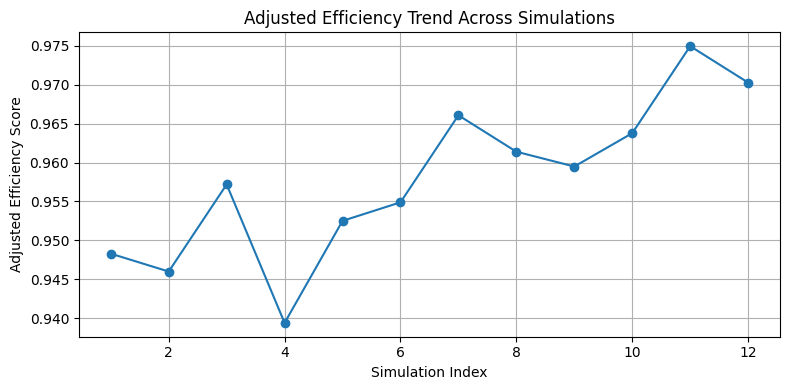

Vessel,Abdominal,Aorta,Coronary
Iteration,,,
1-baseline,72.6,95.7,29.7
2-legs+5,72.9,96.2,29.9
2-neck+5,72.4,95.5,29.6
2-torso+5,73.3,96.6,30.0
2-torso-5,71.9,94.8,29.5
3-legs+5,73.5,97.1,30.1
3-neck+5,73.1,96.4,29.9
3-neck-5,73.4,96.9,30.0
3-torso+5,73.9,97.6,30.2


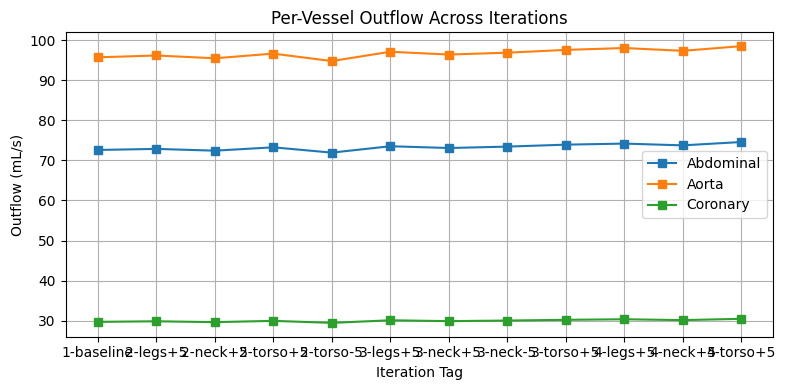

,Segment,Posture,Duration (min),Cumulative Hours
0,1,Neck:+10° Torso:+15° Legs:+5°,30,0.5
1,2,Neck:+10° Torso:+20° Legs:+5°,30,1.0
2,3,Neck:+10° Torso:+25° Legs:+5°,30,1.5
3,4,Neck:+10° Torso:+30° Legs:+5°,30,2.0


[03:21:07] Optimization completed successfully!
[03:21:07] Results stored in: D:\SimVascularProjects\Results
[03:21:07] Run log saved to: D:\SimVascularProjects\Results\20251002-023912_log.txt


{'best_posture': PostureConfig(neck=10, torso=30, legs=5),
 'best_efficiency': np.float64(0.9749652012630842),
 'history': {'trials': [{'posture': PostureConfig(neck=10, torso=15, legs=5),
    'iteration': '1-baseline',
    'flows': {'aorta': {'in': np.float64(85.79899999999999),
      'out': np.float64(95.70878449999998),
      'expected_ratio': 0.97,
      'distribution': {'btrunk': np.float64(11.483174169685038),
       'carotid': np.float64(5.741813729420138),
       'outflow': np.float64(67.00016914205453),
       'rt_carotid': np.float64(5.741813729420138),
       'subclavian': np.float64(5.741813729420138)},
      'resistance_multiplier': 1.0175},
     'abdominal': {'in': np.float64(66.99614914999998),
      'out': np.float64(72.60004204565173),
      'expected_ratio': 0.9423000000000001,
      'distribution': {'SMA': np.float64(7.259951663084499),
       'hepatic': np.float64(2.419952045801574),
       'left_external_iliac': np.float64(18.1502373907944),
       'left_internal_i

In [8]:
# RUN WHEN READY (Heavy Simulations)
# Remove the leading '#' characters to execute the optimization.
example_posture = PostureConfig(neck=10, torso=15, legs=5)
run_summary = run_full_optimization(initial_posture=example_posture, log_label="posture_run")
run_summary

In [10]:
import pickle

# Save run_summary to a pickle file
with open('run_summary.pkl', 'wb') as f:
    pickle.dump(run_summary, f)

print("run_summary saved to 'run_summary.pkl'")
print("To recover in next session, use: with open('run_summary.pkl', 'rb') as f: run_summary = pickle.load(f)")

run_summary saved to 'run_summary.pkl'
To recover in next session, use: with open('run_summary.pkl', 'rb') as f: run_summary = pickle.load(f)
